# Multidomain CLARA tutorial: DAT (Distance Additive Trick)

This notebook reproduces the **empirical application** in the MD-CLARA paper (Section 5) for the **DAT** route.

DAT computes a **domain-specific distance** for each pair of sequences, then **adds** them (here with `link='sum'`). Unlike CAT, each domain may use any distance specification; we use classical OM(1,2) in both domains for comparability with the other tutorials.

**Route-specific diagnostics:** DAT domain contribution shares and leave-one-domain-out stability. Cross-strategy agreement: `md_clara_cross_strategy_diagnostics.ipynb`.


## Step 1 — Imports and paths

In [4]:
# --- Paths (edit if your Sequenzo install lives elsewhere) ---
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
# 若 cwd 不是 xinyi_test，则定位到 notebook 所在目录
if (NOTEBOOK_DIR / "data").is_dir():
    pass  # 已在 xinyi_test
elif (NOTEBOOK_DIR / "tests/archive_test/xinyi_test/data").is_dir():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "tests/archive_test/xinyi_test"
else:
    NOTEBOOK_DIR = Path(__file__).resolve().parent  # 若在 .py 中

DATA_DIR = NOTEBOOK_DIR / "data"
OUTPUT_DIR = NOTEBOOK_DIR / "output"  # 你仓库里已有 output/，不是 outputs/
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# After editing Sequenzo locally: Kernel → Restart, then re-run from Step 1.
# Or uncomment once to force-reload visualization helpers without restart:
# import importlib
# import sequenzo.visualization.utils.utils as _sz_utils
# import sequenzo.multidomain.plot_multidomain_sequence_index as _sz_md_plot
# importlib.reload(_sz_utils)
# importlib.reload(_sz_md_plot)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sequenzo import SequenceData
from sequenzo.multidomain import (
    get_association_between_domains,
    plot_multidomain_sequence_index_by_cluster,
)
from sequenzo.multidomain.clara import (
    md_clara,
    plot_md_clara_quality,
    plot_dat_domain_contributions,
    leave_one_domain_out_sensitivity,
    plot_leave_one_domain_out_sensitivity,
)

DOMAIN_NAMES = ["occupation", "seniority"]

CLARA_R = 25
CLARA_R_DIAG = 15


def clara_sample_size(n_cases: int, max_k: int = 10) -> int:
    return min(1000, max(40 + 2 * max_k, int(0.4 * n_cases)))


TUTORIAL_SUBSET_N = None
RANDOM_STATE = 42


## Step 2 — Load and align the two domain datasets

In [5]:
OCCUPATION_CSV = DATA_DIR / "detailed_sequence_10_work_years_df_clean_year_names_column.csv"
SENIORITY_CSV = DATA_DIR / "detailed_senority_levels_for_10_years_clean_year_names_column.csv"

occupation_df = pd.read_csv(OCCUPATION_CSV)
seniority_df = pd.read_csv(SENIORITY_CSV)

# Keep individuals present in both domains and enforce identical row order.
common_ids = np.intersect1d(occupation_df["worker_id"], seniority_df["worker_id"])
occupation_df = (
    occupation_df[occupation_df["worker_id"].isin(common_ids)]
    .sort_values("worker_id")
    .reset_index(drop=True)
)
seniority_df = (
    seniority_df[seniority_df["worker_id"].isin(common_ids)]
    .sort_values("worker_id")
    .reset_index(drop=True)
)
assert (occupation_df["worker_id"].values == seniority_df["worker_id"].values).all()

if TUTORIAL_SUBSET_N is not None:
    occupation_df = occupation_df.head(TUTORIAL_SUBSET_N).copy()
    seniority_df = seniority_df.head(TUTORIAL_SUBSET_N).copy()

print(f"Individuals: {len(occupation_df):,}")
occupation_df.head()


Individuals: 32,628


,worker_id,gender,country,cohort,1,2,3,4,5,6,7,8,9,10
0,%C2%BBkiran-mummala-narayana-68aaba89,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
1,%E2%86%92-jeremy-mikkola-14455832,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
2,%E2%97%8F%E0%B9%8B-b%C3%A1%DA%A9t%C3%BD%C3%A1v...,male,india,11-20 total work years,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science
3,%E5%A4%A7%E4%BB%BB-%E9%99%B3-880a24110,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
4,%EF%BF%BDgary-m-762b16b8,male,us,21-30 total work years,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware


## Step 3 — Color palettes

We reuse the custom state colors from the original analysis notebook so occupation and seniority index plots stay visually consistent.

In [6]:
# Color palettes from the original LinkedIn sequence-analysis notebook (250814.ipynb).
# One hex code per state, in the same order as OCCUPATION_STATES / SENIORITY_STATES.

OCCUPATION_COLORS = [
    "#659F9F",  # Data
    "#4CA7A7",  # Data science
    "#6BB8C8",  # Software
    "#8CC9E0",  # Hardware
    "#B2C95E",  # Systems & infrastructure
    "#D7D97F",  # Research
    "#E8E1B4",  # Support & test
]

SENIORITY_COLORS = [
    "#E7D4EA",  # Assistant/Junior
    "#D8898C",  # Regular
    "#E14C48",  # Senior
    "#A64F91",  # Leader
    "#6A3D8C",  # Chief/founder
]


## Step 4 — Build `SequenceData` objects

In [7]:
TIME_COLS = [str(i) for i in range(1, 11)]

OCCUPATION_STATES = [
    "Data",
    "Data science",
    "Software",
    "Hardware",
    "Systems & infrastructure",
    "Research",
    "Support & test",
]
SENIORITY_STATES = [
    "Assistant/Junior",
    "Regular",
    "Senior",
    "Leader",
    "Chief/founder",
]

occupation_seq = SequenceData(
    data=occupation_df,
    id_col="worker_id",
    time=TIME_COLS,
    states=OCCUPATION_STATES,
    custom_colors=OCCUPATION_COLORS,
)

seniority_seq = SequenceData(
    data=seniority_df,
    id_col="worker_id",
    time=TIME_COLS,
    states=SENIORITY_STATES,
    custom_colors=SENIORITY_COLORS,
)

domains = [occupation_seq, seniority_seq]
domain_names = ["occupation", "seniority"]

print(f"Domain 1 (occupation): {occupation_seq.seqdata.shape[0]:,} sequences")
print(f"Domain 2 (seniority):  {seniority_seq.seqdata.shape[0]:,} sequences")


[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Data', 'Data science', 'Software', 'Hardware', 'Systems & infrastructure', 'Research', 'Support & test']
[>] Labels: ['Data', 'Data science', 'Software', 'Hardware', 'Systems & infrastructure', 'Research', 'Support & test']
[>] Void: '%' (not in states (inactive); not observed in data) — out-of-window padding; SAMM/seqsamm drops subsequences containing void
[>] Weights: Not provided
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Assistant/Junior', 'Re

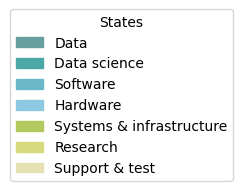

In [8]:
occupation_seq.plot_legend(dpi=300, save_as=str(OUTPUT_DIR / "occupation_legend.png"))

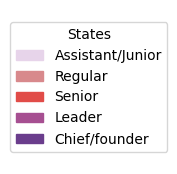

In [9]:
seniority_seq.plot_legend(dpi=300, save_as=str(OUTPUT_DIR / "seniority_legend.png"))

## Step 5 — Measure association between domains

DAT assumes **independence between domain-level distances**. Check association before interpreting the joint typology.

In [10]:
# Optional but recommended: check whether the two domains are associated
# before interpreting a joint multidomain typology.
assoc = get_association_between_domains(
    domains,
    assoc=("LRT", "V"),
    dnames=domain_names,
    explain=True,
)
assoc



📜 Full results table:


,df,LRT,p(LRT),v,p(v),strength
occupation vs seniority,24.0,17434.505964,0.000 ***,0.141299,0.000 ***,Weak



📘 Column explanations:
  - df       : Degrees of freedom for the test (typically 1 for binary state sequences).
  - LRT      : Likelihood Ratio Test statistic (higher = stronger dependence).
  - p(LRT)   : p-value for LRT + significance stars: * (p<.05), ** (p<.01), *** (p<.001)
  - v        : Cramer's V statistic (0 to 1, measures association strength).
  - p(v)     : p-value for Cramer's V (based on chi-squared test) + significance stars: * (p<.05), ** (p<.01), *** (p<.001)
  - strength : Qualitative label for association strength based on Cramer's V:
               0.00-0.09 -> None, 0.10-0.29 -> Weak, 0.30-0.49 -> Moderate, >=0.50 -> Strong


## Step 6 — Configure DAT distance parameters

`method_params` is a **list of dicts**, one per domain. Each dict is passed to the usual single-domain distance function (here: OM with constant costs).

In [11]:
N_DOMAINS = len(domains)
OM_PARAMS = {"method": "OM", "sm": "CONSTANT", "indel": 1, "norm": "none"}

distance_params = {
    "method_params": [dict(OM_PARAMS) for _ in range(N_DOMAINS)],
    "domain_weights": [1.0] * N_DOMAINS,
    "link": "sum",  # multidomain distance = weighted sum of domain distances
}

distance_params


{'method_params': [{'method': 'OM',
   'sm': 'CONSTANT',
   'indel': 1,
   'norm': 'none'},
  {'method': 'OM', 'sm': 'CONSTANT', 'indel': 1, 'norm': 'none'}],
 'domain_weights': [1.0, 1.0],
 'link': 'sum'}

## Step 7 — Run MD-CLARA with `strategy='dat'`

For large samples, keep `n_jobs=1` when using parallel CLARA repetitions elsewhere; set `distance_params['n_jobs_domains']` if you run CLARA serially but want parallel domain-distance calls.

In [12]:
N = occupation_seq.seqdata.shape[0]
sample_size = clara_sample_size(N, max_k=10)
print(f"N = {N:,} | b = {sample_size} | R = {CLARA_R}")

result = md_clara(
    domains,
    strategy="dat",
    distance_params=distance_params,
    R=CLARA_R,
    sample_size=sample_size,
    kvals=list(range(2, 11)),
    criteria=("distance",),
    stability=True,
    dat_domain_contribution=True,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=True,
)

result.stats


N = 32,628 | b = 1000 | R = 25
[>] Starting multidomain CLARA with distance provider.
  - Strategy sample size: 1000, iterations: 25
  - Within-subsample storage: condensed; medoid cache: False
[>] Running CLARA iterations...
  - Done.
[>] Aggregating iterations for each k...


,k,total_diss,avg_dist,pbm,db,xb,ams,ari08,jc08,best_iter,criterion,R,sample_size,strategy
0,2,374604.0,11.481059,0.371734,1.696460,0.820076,0.533477,0.0,0.0,4.0,distance,25,1000,dat
1,3,336336.0,10.308202,0.941097,1.129580,0.736300,0.508115,0.0,0.0,4.0,distance,25,1000,dat
2,4,292668.0,8.969842,0.795445,1.089906,0.640703,0.556422,0.0,0.0,4.0,distance,25,1000,dat
3,5,269354.0,8.255302,0.760675,1.363253,0.825530,0.542469,0.0,0.0,4.0,distance,25,1000,dat
4,6,274438.0,8.411119,0.628217,1.306334,0.700927,0.511323,0.0,0.0,20.0,distance,25,1000,dat
5,7,261466.0,8.013547,0.508481,1.079664,0.667796,0.528975,0.0,0.0,5.0,distance,25,1000,dat
6,8,246818.0,7.564607,0.436885,1.292880,1.260768,0.540122,0.0,0.0,14.0,distance,25,1000,dat
7,9,232448.0,7.124188,0.389192,1.116252,0.593682,0.556193,0.0,0.0,24.0,distance,25,1000,dat
8,10,225342.0,6.906399,0.335441,1.226430,0.863300,0.550754,0.0,0.0,24.0,distance,25,1000,dat


## Step 8 — Inspect cluster quality and stability

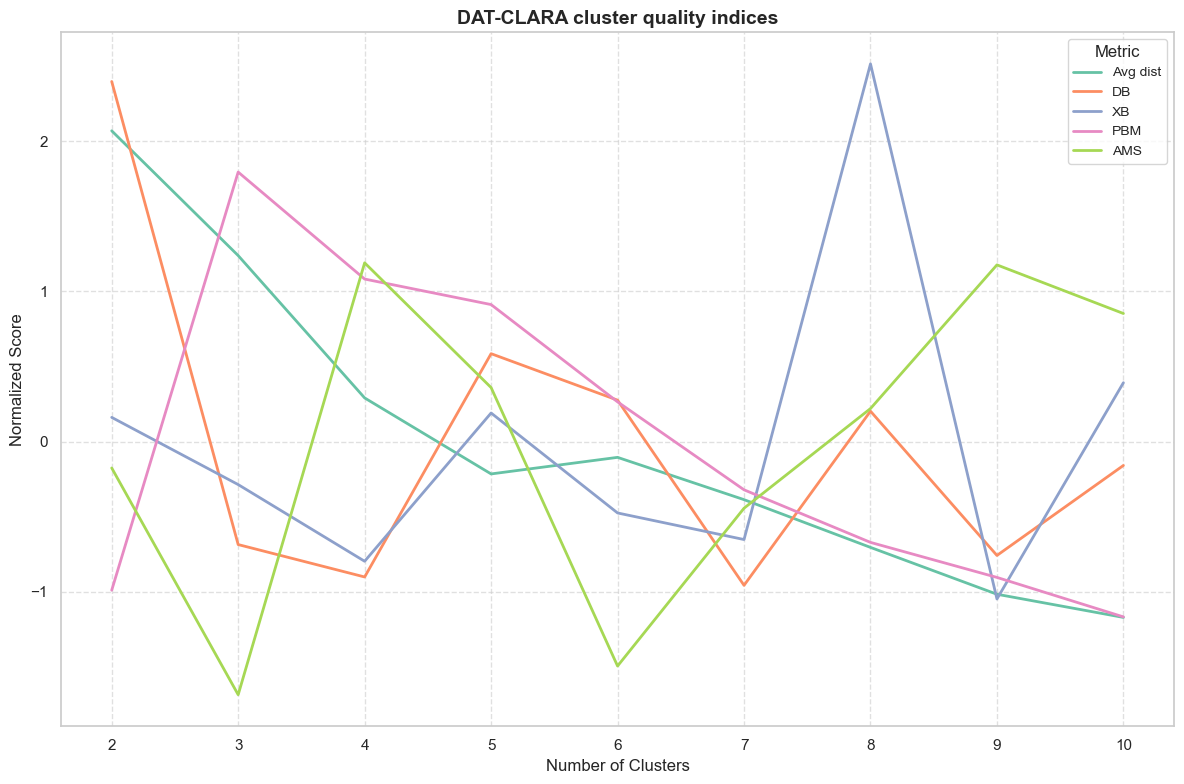

In [14]:
plot_md_clara_quality(
    result,
    title="DAT-CLARA cluster quality indices",
    save_as=str(OUTPUT_DIR / "dat_clara_quality.png"),
)


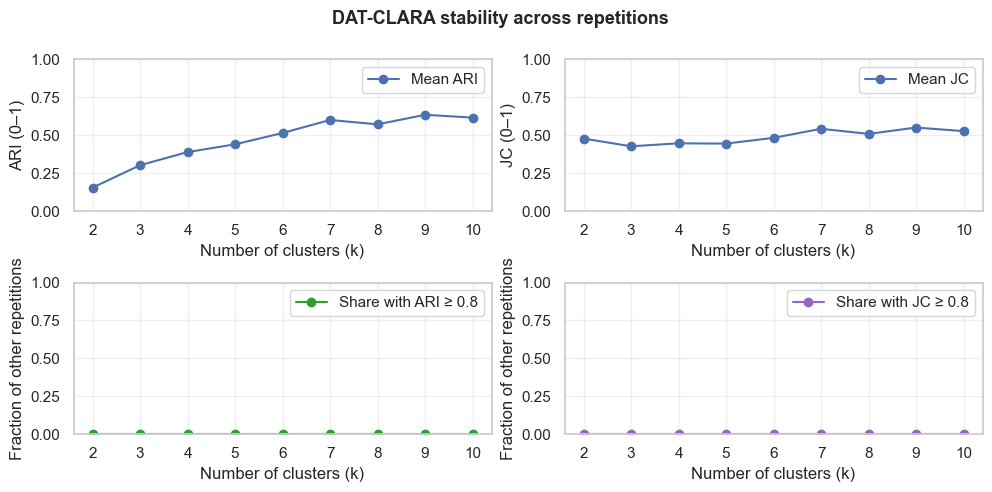

In [15]:
if result.stability:
    from sequenzo.multidomain.clara import plot_md_clara_stability
    plot_md_clara_stability(
        result,
        title="DAT-CLARA stability across repetitions",
        save_as=str(OUTPUT_DIR / "dat_clara_stability.png"),
    )


## Step 9 — Choose k and inspect cluster labels

In [16]:
# Helper: pick k with the lowest average distance (simple heuristic).
# best_k = int(result.stats.loc[result.stats["avg_dist"].idxmin(), "k"])
best_k = 6
print(f"Suggested k (lowest avg_dist): {best_k}")

labels = result.best_clustering(best_k)

# Cluster labels are stored with worker_id as the row index.
clustering_df = result.clustering.reset_index().rename(columns={"index": "worker_id"})
cluster_col = f"Cluster {best_k}"
clustering_df["cluster"] = clustering_df[cluster_col]
clustering_df.head()


Suggested k (lowest avg_dist): 6


,worker_id,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,cluster
0,%C2%BBkiran-mummala-narayana-68aaba89,2,3,4,3,3,4,2,9,9,3
1,%E2%86%92-jeremy-mikkola-14455832,2,3,4,3,3,4,2,9,9,3
2,%E2%97%8F%E0%B9%8B-b%C3%A1%DA%A9t%C3%BD%C3%A1v...,1,2,3,4,4,7,6,2,2,4
3,%E5%A4%A7%E4%BB%BB-%E9%99%B3-880a24110,1,2,3,4,4,2,6,5,6,4
4,%EF%BF%BDgary-m-762b16b8,2,3,4,3,5,1,2,4,5,5


## Step 10 — Sequence index plots coloured by cluster

For each domain, Sequenzo builds a **column** sequence-index plot (one row per cluster, all sequences in that cluster), then stitches occupation and seniority side by side. Row order within a cluster is aligned across domains (from the first domain). On the full DAT sample this step can take several minutes.

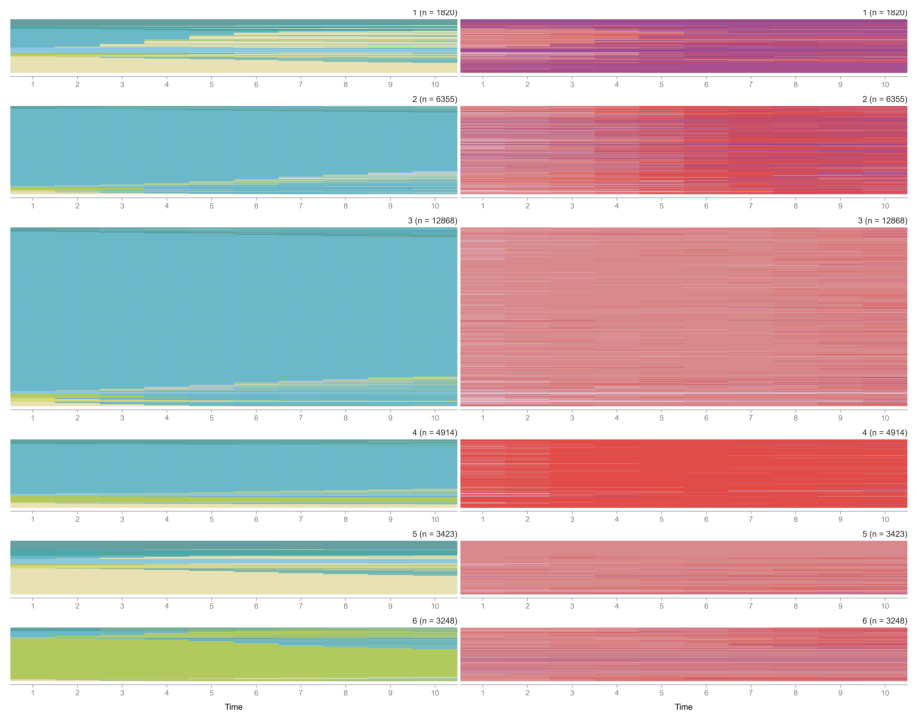

{1: array(['aaron-warner-885690241', 'aayush-bhutani-891476189',
        'abha-sarmukaddam-8ba829a6', ..., 'yogesh-phutane-a74477a',
        'zach-wendal-61542a54', 'zahid-mansoor-81b5b427'], dtype=object),
 2: array(['aakanksha-taneja-65840566', 'aarti-balam-09ab2071',
        'ann-neidenbach-bb15417', ..., 'ramya-kozhummal-74477886',
        'ravi-likhar-25711342', 'richard-perfetti-64725515'], dtype=object),
 3: array(['abhishek-saxena-7537047b', 'ajit-rajput-b6a58162', 'ajitrajput80',
        ..., 'shashishekhar-h-m-7a671715', 'srinivasa-rao-arava-874202133',
        'vaibhav-mehta-33249a56'], dtype=object),
 4: array(['abe-elzarad-8548a44', 'adam-trexler-177a80242',
        'adlay-almeida-356639b0', ..., 'yellaiah-kola-4a5b8321b',
        'yogesh-biswas-qe', 'zach-christiansen-77221817'], dtype=object),
 5: array(['aaron-durchenwald-48843b5', 'aarthi-narayan-066a1146',
        'abdullahabdeen', ..., 'yuhendran',
        'zhixin-zhu-%E6%9C%B1%E5%BF%97%E9%A6%A8-42835821',
        'z

In [17]:
# Sequence index: per-domain column plots (rows = clusters), stitched horizontally.
plot_df = occupation_df.merge(
    clustering_df[["worker_id", "cluster"]],
    on="worker_id",
    how="left",
).rename(columns={"worker_id": "Entity ID", "cluster": "Cluster"})

plot_multidomain_sequence_index_by_cluster(
    seqdata_list=domains,
    group_dataframe=plot_df,
    group_column_name="Cluster",
    domain_names=["Occupation", "Seniority"],
    include_legend=False,
    dpi=300,
    save_as=str(OUTPUT_DIR / f"dat_clara_k{best_k}_sequence_index_by_cluster.png"),
)


## Step 11 — DAT domain contribution shares

For `strategy='dat'`, decompose weighted within-cluster dissimilarity by domain. Shares sum to 1 within each cluster (and for the pooled `all` row). Requires `dat_domain_contribution=True` in Step 7.


In [18]:
route = result.route_diagnostics or {}
contrib_by_k = route.get("dat_domain_contributions", {})
if best_k not in contrib_by_k:
    raise KeyError(
        f"No DAT contributions stored for k={best_k}. "
        "Re-run md_clara with dat_domain_contribution=True."
    )
contrib = contrib_by_k[best_k]
contrib[contrib["cluster"] == "all"]


,domain,cluster,weighted_distance,contribution_share,contribution_defined
0,domain_0,all,139902.0,0.509776,True
1,domain_1,all,134536.0,0.490224,True


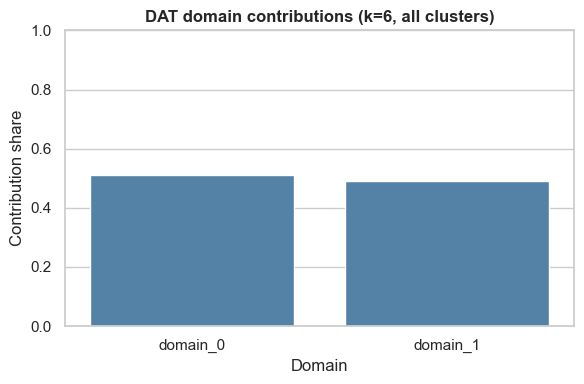

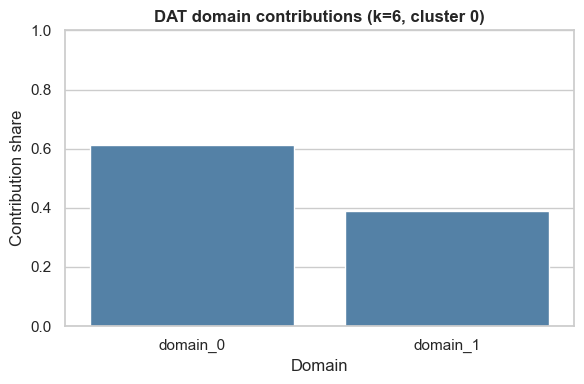

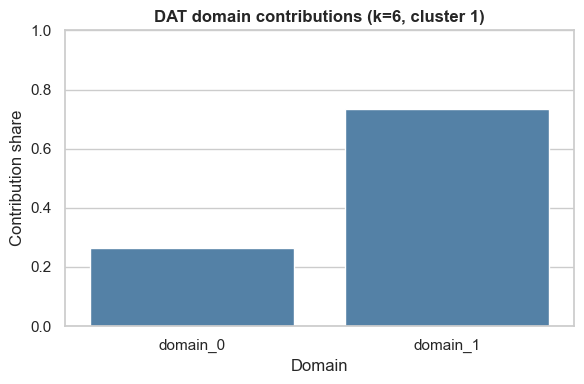

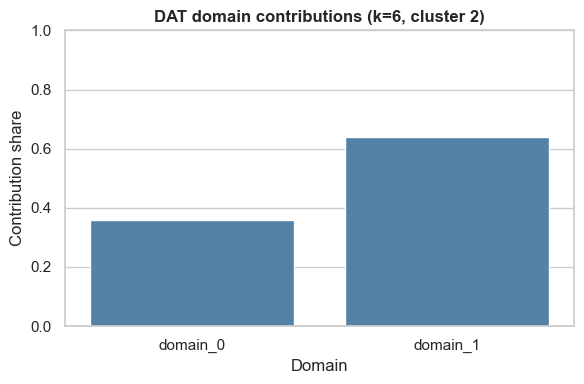

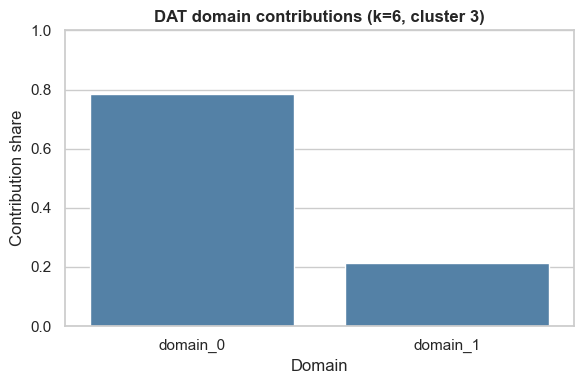

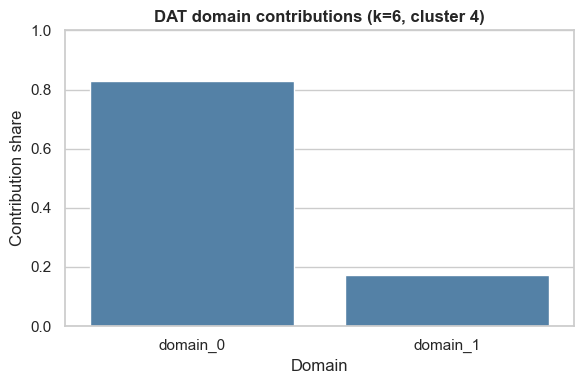

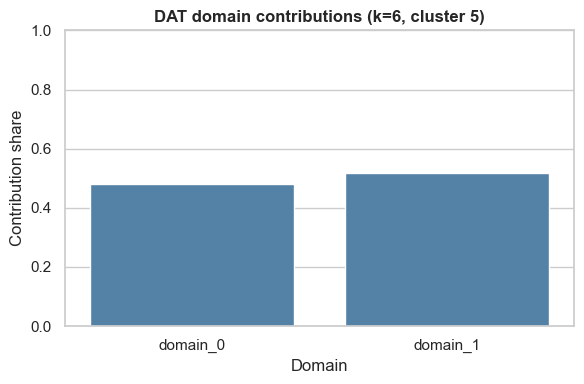

In [20]:
plot_dat_domain_contributions(
    contrib,
    cluster="all",
    title=f"DAT domain contributions (k={best_k}, all clusters)",
    save_as=str(OUTPUT_DIR / f"dat_domain_contributions_k{best_k}.png"),
)
plt.show()

for cluster_id in sorted(contrib.loc[contrib["cluster"] != "all", "cluster"].unique()):
    if cluster_id == "all":
        continue
    plot_dat_domain_contributions(
        contrib,
        cluster=cluster_id,
        title=f"DAT domain contributions (k={best_k}, cluster {cluster_id})",
        save_as=str(OUTPUT_DIR / f"dat_domain_contributions_k{best_k}_c{cluster_id}.png"),
    )


## Step 12 — Leave-one-domain-out stability

Re-fit MD-CLARA after omitting one domain at a time and compare partitions to the **all-domain** solution (ARI). Uses `CLARA_R_DIAG` repetitions.

With two domains, the reduced model is single-domain CLARA on the retained sequence.


In [21]:
loo = leave_one_domain_out_sensitivity(
    domains,
    strategy="dat",
    k=best_k,
    R=CLARA_R_DIAG,
    sample_size=sample_size,
    distance_params=distance_params,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=True,
)
loo["domain"] = [DOMAIN_NAMES[i] for i in loo["omitted_domain_index"]]
loo


[>] Starting multidomain CLARA with distance provider.
  - Strategy sample size: 1000, iterations: 15
  - Within-subsample storage: condensed; medoid cache: False
[>] Running CLARA iterations...
  - Done.
[>] Aggregating iterations for each k...
[>] Starting generalized CLARA for sequence analysis.
[>] Using crisp clustering optimizing the following criterion: distance.
  - Aggregating 32628 sequences...
  - OK (1745 unique cases).
[>] Starting iterations...
  - Done.
[>] Aggregating iterations for each k values...
  - Done.
[>] Starting generalized CLARA for sequence analysis.
[>] Using crisp clustering optimizing the following criterion: distance.
  - Aggregating 32628 sequences...
  - OK (2006 unique cases).
[>] Starting iterations...
  - Done.
[>] Aggregating iterations for each k values...
  - Done.


,omitted_domain,omitted_domain_index,strategy,k,ari_vs_all_domains,jaccard_vs_all_domains,full_requested_sample_size,full_effective_sample_size,full_n_unique_profiles,reduced_requested_sample_size,reduced_effective_sample_size,reduced_n_unique_profiles,reduced_model,domain
0,domain_0,0,dat,6,0.463614,0.441216,1000,1000,7055,1000,1000,None,clara_single_domain,occupation
1,domain_1,1,dat,6,0.267340,0.340021,1000,1000,7055,1000,1000,None,clara_single_domain,seniority


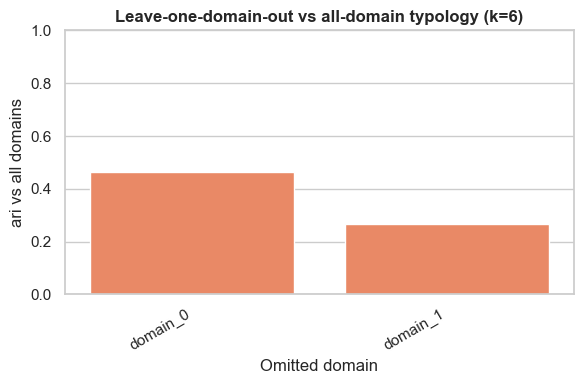

In [22]:
plot_leave_one_domain_out_sensitivity(
    loo,
    metric="ari_vs_all_domains",
    title=f"Leave-one-domain-out vs all-domain typology (k={best_k})",
    save_as=str(OUTPUT_DIR / f"dat_loo_sensitivity_k{best_k}.png"),
)
plt.show()


## Step 13 — Save results


In [23]:
result.stats.to_csv(OUTPUT_DIR / "dat_clara_stats.csv", index=False)
clustering_df.to_csv(OUTPUT_DIR / f"dat_clara_clustering_k{best_k}.csv", index=False)
print("Saved outputs to", OUTPUT_DIR)
loo.to_csv(OUTPUT_DIR / f"dat_loo_sensitivity_k{best_k}.csv", index=False)
contrib.to_csv(OUTPUT_DIR / f"dat_domain_contributions_k{best_k}.csv", index=False)


Saved outputs to /Users/xinyi/Projects/sequenzo/sequenzo/sequenzo310/Sequenzo/tests/archive_test/xinyi_test/output


---

### What you learned

- **DAT** adds **domain-specific distances** (OM(1,2) here in each domain).
- **`dat_domain_contribution=True`** attaches domain contribution shares to `result.route_diagnostics`.
- **Leave-one-domain-out** stability shows how much each domain shapes the joint typology.
- Cross-strategy agreement: `md_clara_cross_strategy_diagnostics.ipynb`.
- Compare with `idcd_md_clara_tutorial.ipynb` and `cat_md_clara_tutorial.ipynb`.
